# ECDF-difference of s per site — SV / indel vs frequency-matched SNP

A histogram can't resolve a shift that is small relative to the distribution width, and smaller bins
only add noise. The **cumulative** difference can. For each site:

$$\Delta\mathrm{CDF}(x) = P(s_{\text{class}} \le x) - P(s_{\text{matched SNP}} \le x)$$

- **x = selection coefficient s** (same axis as the histogram); **y = difference in cumulative
  probability** (not selection).
- **Positive hump** ⇒ the class has more mass at/below that s than a same-frequency SNP ⇒ its
  distribution is **left-shifted (more purged)**. The peak height ≈ the KS statistic. **Flat at 0**
  ⇒ identical distributions.
- Frequency-matched (SNP/indel resampled to the SV p₀ distribution); no MAF filter. Sites cold→hot.

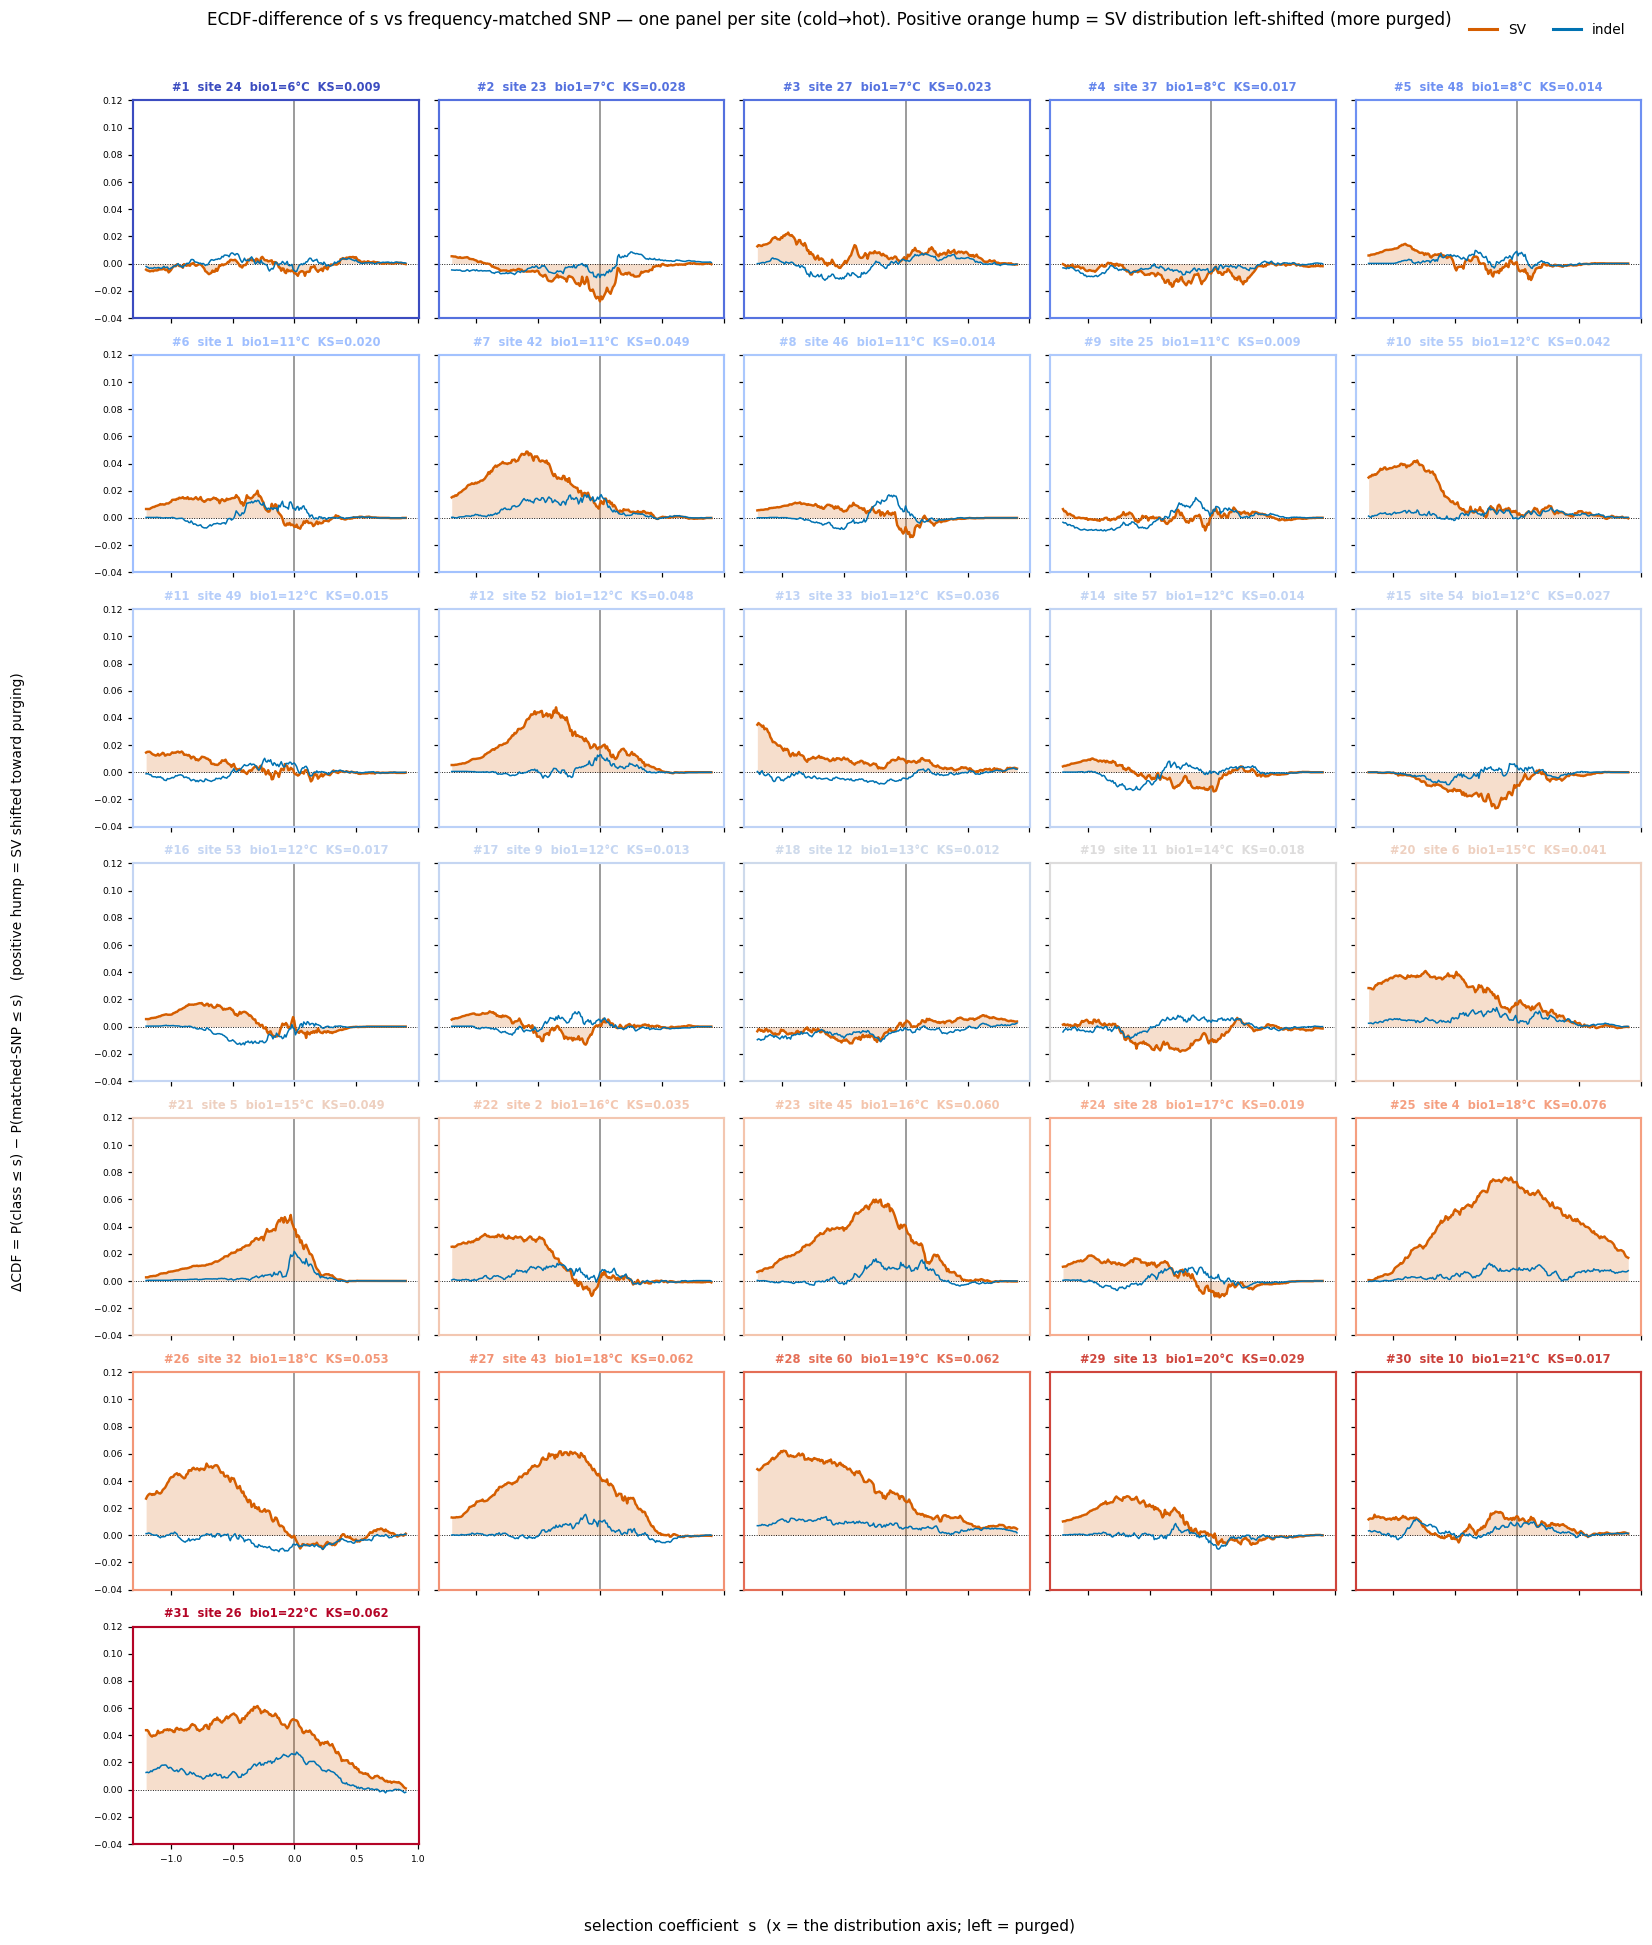

saved s_ecdf_difference_by_site.png


In [1]:

import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
plt.rcParams.update({'figure.dpi':110,'font.size':8,'axes.linewidth':0.6})
G = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/sv_adaptive"
npz = np.load(f"{G}/s_dist_by_stratum.npz")
meta = pd.read_csv(f"{G}/s_dist_by_stratum_sitemeta.csv").sort_values("bio1").reset_index(drop=True)
COL = {"indel":"#0072B2","SV":"#D55E00"}
NBIN, NDRAW = 25, 20000; rng = np.random.default_rng(0)
GRID = np.linspace(-1.2, 0.9, 220)

def match_to(tp0, ss, sp0):
    e=np.quantile(np.concatenate([tp0,sp0]),np.linspace(0,1,NBIN+1)); e[-1]+=1e-9
    tb=np.digitize(tp0,e[1:-1]); sb=np.digitize(sp0,e[1:-1]); out=[]
    for b in range(NBIN):
        k=int(round((tb==b).mean()*NDRAW)); pool=ss[sb==b]
        if k>0 and pool.size: out.append(rng.choice(pool,k,replace=True))
    return np.concatenate(out)
def cdf(s): ss=np.sort(s); return np.searchsorted(ss, GRID, side="right")/ss.size

sites = meta.site.tolist()                      # already ascending in bio1
ncol, nrow = 5, int(np.ceil(len(sites)/5))
norm = mpl.colors.Normalize(vmin=meta.bio1.min(), vmax=meta.bio1.max()); cmap = mpl.cm.coolwarm
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.5*nrow), sharex=True, sharey=True)
axes = axes.ravel()
for ax in axes[len(sites):]: ax.axis("off")
for i, s in enumerate(sites):
    ax = axes[i]
    p_sv = npz[f"{s}_p0_SV"]
    base = cdf(match_to(p_sv, npz[f"{s}_s_SNP"], npz[f"{s}_p0_SNP"]))
    dsv = cdf(npz[f"{s}_s_SV"]) - base
    din = cdf(match_to(p_sv, npz[f"{s}_s_indel"], npz[f"{s}_p0_indel"])) - base
    ax.axhline(0, color="k", lw=0.6, ls=":")
    ax.axvline(0, color="0.5", lw=1.0, zorder=1)   # s = 0 (neutral) reference
    ax.fill_between(GRID, 0, dsv, color=COL["SV"], alpha=0.20, lw=0)
    ax.plot(GRID, dsv, color=COL["SV"], lw=1.6)
    ax.plot(GRID, din, color=COL["indel"], lw=1.0)
    b1 = meta[meta.site==s].bio1.iloc[0]
    c = cmap(norm(b1))                          # cold=blue -> hot=red panel colour
    ax.set_title(f"#{i+1}  site {s}  bio1={b1:.0f}°C  KS={np.abs(dsv).max():.03f}",
                 fontsize=7.5, color=c, fontweight="bold")
    for sp in ax.spines.values(): sp.set_color(c); sp.set_linewidth(1.4)
    ax.tick_params(labelsize=6)
# colour-graded numbered titles/borders (#1 cold -> #31 hot) already encode bio1; no colorbar needed
axes[0].set_ylim(-0.04, 0.12)
fig.supxlabel("selection coefficient  s  (x = the distribution axis; left = purged)", y=0.005, fontsize=10)
fig.supylabel("ΔCDF = P(class ≤ s) − P(matched-SNP ≤ s)   (positive hump = SV shifted toward purging)",
              x=0.004, fontsize=9)
fig.legend(handles=[Line2D([0],[0],color=COL[c],lw=2,label=c) for c in ["SV","indel"]],
           loc="upper right", ncol=2, fontsize=9, frameon=False, bbox_to_anchor=(0.99,1.004))
fig.suptitle("ECDF-difference of s vs frequency-matched SNP — one panel per site (cold→hot). "
             "Positive orange hump = SV distribution left-shifted (more purged)", fontsize=11, y=1.004)
fig.tight_layout(rect=[0.03,0.02,1,0.99])
fig.savefig(f"{G}/s_ecdf_difference_by_site.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved s_ecdf_difference_by_site.png")


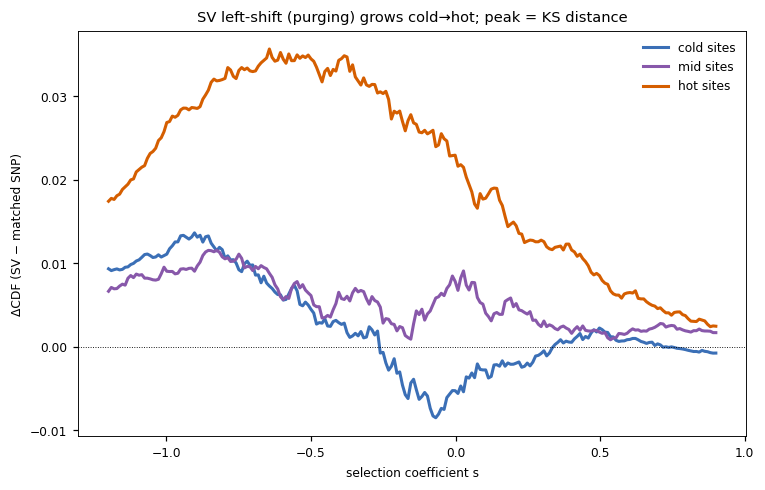

In [2]:

terc = pd.qcut(meta.bio1, 3, labels=["cold","mid","hot"])
tcol = {"cold":"#3B6FB6","mid":"#8858AA","hot":"#D55E00"}
fig, ax = plt.subplots(figsize=(7,4.5))
for t in ["cold","mid","hot"]:
    ss = meta.site[terc.values==t].tolist()
    sv=np.concatenate([npz[f"{s}_s_SV"] for s in ss]); psv=np.concatenate([npz[f"{s}_p0_SV"] for s in ss])
    m=match_to(psv, np.concatenate([npz[f"{s}_s_SNP"] for s in ss]),
                     np.concatenate([npz[f"{s}_p0_SNP"] for s in ss]))
    ax.plot(GRID, cdf(sv)-cdf(m), color=tcol[t], lw=2, label=f"{t} sites")
ax.axhline(0,color="k",lw=0.6,ls=":")
ax.set_xlabel("selection coefficient s"); ax.set_ylabel("ΔCDF (SV − matched SNP)")
ax.set_title("SV left-shift (purging) grows cold→hot; peak = KS distance"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(f"{G}/s_ecdf_difference_summary.png", dpi=130, bbox_inches="tight"); plt.show()


### Reading
- **indel (blue) ≈ 0** everywhere → indels are the same distribution as SNPs.
- **SV (orange) = a positive hump** over the negative-s (purged) range at warm sites, ~0 at cold
  sites. The hump height (≈ KS, in the titles) is how much extra SV mass sits below a given s — a few
  percent. That is the same small, real, climate-linked purifying shift the mean/scatter showed, now
  as a *distribution* view that doesn't need the eye to spot a small offset between overlaid curves.
- Small hump = genuinely small effect (a few % of probability mass), not a dramatic per-SV difference.